# Laboratorio 3 - Embeddings y Representación Semántica
**Pontificia Universidad Católica del Ecuador**  
**Facultad de Ciencias Exactas, Naturales y Ambientales**  
**Carrera de Ciencia de Datos**  
**Procesamiento Natural del Lenguaje**

## Actividad 0: Instalación y Carga de Modelos

In [ ]:
# Instalación de librerías
!pip install gensim sentence-transformers umap-learn plotly --quiet

In [ ]:
# ================================================
# LABORATORIO III: Embeddings y Representación Semántica
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Librerias base importadas correctamente.")

Librerias base importadas correctamente.


In [ ]:
# ==================== CARGA DEL DATASET ====================
# Se usa el dataset oficial del curso alojado en GitHub.
# Contiene 200 frases complejas en español (con emojis y mezcla de idiomas).

df = pd.read_csv(
    "https://raw.githubusercontent.com/danirodriguez4657/procesamiento_lenguaje_natural/refs/heads/main/dataset_lab3.csv"
)

print(f"Dataset cargado: {df.shape[0]} registros")
print(f"Columnas disponibles: {df.columns.tolist()}")
print()
print(df.head(10))

Dataset cargado: 200 registros
Columnas disponibles: ['id', 'frase']

   id                                              frase
0   1  Al mal tiempo, buena 🌦️. Hay que mantener el s...
1   2  El 💰 no compra la happiness, pero ayuda a Cruz...
2   3  Más vale pájaro en mano que Ciento Volando, qu...
3   4  La vida es una caja de chocolates, nunca sabes...
4   5  No dejes para mañana lo que puedas hacer today...
5   6  A caballo regalado no se le mira el Diente, qu...
6   7  Camarón que se duerme se lo lleva la Corriente...
7   8  Mucho ruido y pocas nueces, eso me pone muy 😢 ...
8   9  De tal palo, tal astilla; un hijo muy 😊 con su...
9  10  El que madruga Dios lo ayuda con mucho 💰 y salud.


---
## Actividad 1: One-Hot Encoding y sus Limitaciones

In [ ]:
print("=== ACTIVIDAD 1: One-Hot Encoding ===")

# --- 1.1 Implementación manual de One-Hot Encoding ---

vocabulario_manual = [
    "perro", "gato", "casa", "árbol", "agua",
    "feliz", "triste", "correr", "dormir", "comer",
    "ciudad", "campo", "río", "montaña", "libro",
    "escuela", "trabajo", "amor", "tiempo", "sol"
]

def one_hot_manual(palabra, vocabulario):
    """Genera el vector one-hot para una palabra dada."""
    vector = np.zeros(len(vocabulario), dtype=int)
    if palabra in vocabulario:
        vector[vocabulario.index(palabra)] = 1
    return vector

palabras_ejemplo = ["perro", "gato", "feliz", "triste", "ciudad"]

print("\nVectores One-Hot (primeras 10 dimensiones):")
print(f"{'Palabra':<12} {'Vector (dim 0-9)'}")
print("-" * 50)
for p in palabras_ejemplo:
    vec = one_hot_manual(p, vocabulario_manual)
    print(f"{p:<12} {vec[:10]}")

=== ACTIVIDAD 1: One-Hot Encoding ===

Vectores One-Hot (primeras 10 dimensiones):
Palabra      Vector (dim 0-9)
--------------------------------------------------
perro        [1 0 0 0 0 0 0 0 0 0]
gato         [0 1 0 0 0 0 0 0 0 0]
feliz        [0 0 0 0 0 1 0 0 0 0]
triste       [0 0 0 0 0 0 1 0 0 0]
ciudad       [0 0 0 0 0 0 0 0 0 0]


In [ ]:
# --- 1.2 One-Hot con CountVectorizer ---

textos = df["frase"].astype(str).tolist()[:100]

vectorizer = CountVectorizer(binary=True, lowercase=True, max_features=500)
X_onehot = vectorizer.fit_transform(textos)

print(f"Dimensiones de la matriz One-Hot: {X_onehot.shape}")
print(f"(filas = frases, columnas = tokens del vocabulario)")

idx = 0
print(f"\nFrase de ejemplo: '{textos[idx]}'")
print(f"Numero de unos en su vector: {X_onehot[idx].sum()}")

Dimensiones de la matriz One-Hot: (100, 431)
(filas = frases, columnas = tokens del vocabulario)

Frase de ejemplo: 'Al mal tiempo, buena 🌦️. Hay que mantener el smile siempre.'
Numero de unos en su vector: 10


In [ ]:
# --- 1.3 Distancias entre vectores One-Hot ---

# Construimos vectores one-hot para palabras individuales del vocabulario manual
pares = [
    ("perro", "gato"),
    ("perro", "feliz"),
    ("feliz", "triste"),
    ("ciudad", "campo")
]

print("Comparacion de distancias entre pares de palabras:")
print(f"{'Par':<25} {'Coseno':>10} {'Euclidiana':>12}")
print("-" * 50)

for p1, p2 in pares:
    v1 = one_hot_manual(p1, vocabulario_manual).reshape(1, -1)
    v2 = one_hot_manual(p2, vocabulario_manual).reshape(1, -1)
    cos  = cosine_similarity(v1, v2)[0][0]
    eucl = euclidean_distances(v1, v2)[0][0]
    print(f"{p1+' vs '+p2:<25} {cos:>10.4f} {eucl:>12.4f}")

print()
print("Observacion: la distancia coseno entre cualquier par de palabras")
print("distintas es siempre 0.0 (ortogonales) y la euclidiana siempre 1.414.")
print("Esto confirma que One-Hot no captura ninguna relacion semantica.")

Comparacion de distancias entre pares de palabras:
Par                           Coseno   Euclidiana
--------------------------------------------------
perro vs gato                 0.0000       1.4142
perro vs feliz                0.0000       1.4142
feliz vs triste               0.0000       1.4142
ciudad vs campo               0.0000       1.4142

Observacion: la distancia coseno entre cualquier par de palabras
distintas es siempre 0.0 (ortogonales) y la euclidiana siempre 1.414.
Esto confirma que One-Hot no captura ninguna relacion semantica.


In [ ]:
# --- 1.4 Matriz de similitud coseno entre las primeras 10 frases ---

sim_coseno = cosine_similarity(X_onehot[:10])

plt.figure(figsize=(9, 7))
sns.heatmap(
    np.round(sim_coseno, 2),
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[f"F{i+1}" for i in range(10)],
    yticklabels=[f"F{i+1}" for i in range(10)]
)
plt.title("Matriz de Similitud Coseno - One-Hot (primeras 10 frases)", fontsize=13)
plt.tight_layout()
plt.savefig("similitud_onehot.png", dpi=120)
plt.show()

### Analisis - Actividad 1

**Por que One-Hot no captura semantica:**

El One-Hot Encoding asigna a cada palabra un vector ortogonal en un espacio de dimensión igual al tamaño del vocabulario. Esto implica que:

1. **Distancia uniforme**: la distancia entre *perro* y *gato* es idéntica a la distancia entre *perro* y *libro*. El modelo no distingue entre palabras semánticamente cercanas y lejanas.

2. **Sin relaciones entre palabras**: no existe ningún mecanismo que permita al modelo aprender que *feliz* y *alegre* son sinónimos, o que *rey* y *reina* comparten el campo semántico de la realeza.

3. **Alta dimensionalidad**: el vector crece linealmente con el vocabulario (puede superar las 100.000 dimensiones en corpora reales), generando matrices extremadamente dispersas.

4. **Problema OOV**: cualquier palabra fuera del vocabulario entrenado no tiene representación posible.

---
## Actividad 2: Entrenamiento de Word2Vec desde Cero

In [ ]:
print("=== ACTIVIDAD 2: Entrenamiento Word2Vec ===")

import re
from gensim.models import Word2Vec

# --- 2.1 Preprocesamiento ---
# El dataset contiene emojis, palabras en ingles y signos de puntuacion.
# Se eliminan para obtener tokens limpios en espanol.

def preprocesar(texto):
    """Limpia emojis, caracteres especiales, numeros y tokeniza en minusculas."""
    texto = str(texto)
    # Eliminar emojis codificados fuera del rango ASCII
    texto = texto.encode("ascii", "ignore").decode("ascii")
    texto = texto.lower()
    # Conservar solo letras y espacios
    texto = re.sub(r"[^a-z ]", "", texto)
    tokens = [t for t in texto.split() if len(t) > 2]
    return tokens

df["tokens"] = df["frase"].apply(preprocesar)
corpus = df["tokens"].tolist()

frase_orig   = df["frase"].iloc[0]
tokens_orig  = df["tokens"].iloc[0]
vocab_size   = len(set(t for tokens in corpus for t in tokens))

print("Ejemplo de tokenizacion:")
print("  Original :", frase_orig)
print("  Tokens   :", tokens_orig)
print("  Total de oraciones en el corpus:", len(corpus))
print("  Vocabulario estimado:", vocab_size, "tokens unicos")

=== ACTIVIDAD 2: Entrenamiento Word2Vec ===
Ejemplo de tokenizacion:
  Original : Al mal tiempo, buena 🌦️. Hay que mantener el smile siempre.
  Tokens   : ['mal', 'tiempo', 'buena', 'hay', 'que', 'mantener', 'smile', 'siempre']
  Total de oraciones en el corpus: 200
  Vocabulario estimado: 704 tokens unicos


In [ ]:
# --- 2.2 Entrenamiento Skip-Gram ---

model_sg = Word2Vec(
    sentences=corpus,
    vector_size=150,
    window=5,
    min_count=1,   # min_count=1 porque el corpus es pequeño
    sg=1,          # 1 = Skip-Gram
    epochs=30,
    workers=4,
    seed=42
)

print(f"Vocabulario Skip-Gram: {len(model_sg.wv)} palabras")

# --- 2.3 Entrenamiento CBOW ---

model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=150,
    window=5,
    min_count=1,
    sg=0,          # 0 = CBOW
    epochs=30,
    workers=4,
    seed=42
)

print(f"Vocabulario CBOW     : {len(model_cbow.wv)} palabras")

Vocabulario Skip-Gram: 704 palabras
Vocabulario CBOW     : 704 palabras


In [ ]:
# --- 2.4 Exploración de vectores y similitudes ---
# Las consultas se adaptan a palabras que razonablemente aparecen en el dataset.

vocab = list(model_sg.wv.key_to_index.keys())
print(f"Muestra del vocabulario aprendido: {vocab[:20]}")
print()

# Usar palabras que existan en el vocabulario entrenado
consultas = [w for w in ["vida", "tiempo", "bien", "mal", "hombre", "dios", "palo"] if w in model_sg.wv]
consultas = consultas[:4]  # tomar solo 4

for modelo_nombre, modelo in [("Skip-Gram", model_sg), ("CBOW", model_cbow)]:
    print(f"--- {modelo_nombre} ---")
    for palabra in consultas:
        similares = modelo.wv.most_similar(palabra, topn=4)
        print(f"  Similares a '{palabra}': {similares}")

Muestra del vocabulario aprendido: ['que', 'una', 'con', 'los', 'surprise', 'del', 'las', 'life', 'pero', 'para', 'smile', 'tiene', 'muy', 'happiness', 'gran', 'mucha', 'heart', 'quien', 'hace', 'vale']

--- Skip-Gram ---
  Similares a 'vida': [('una', 0.9962731599807739), ('que', 0.9960306286811829), ('happiness', 0.9959012269973755), ('los', 0.9958104491233826)]
  Similares a 'tiempo': [('que', 0.9969165325164795), ('pero', 0.9965729117393494), ('con', 0.9964208006858826), ('una', 0.9963887929916382)]
  Similares a 'bien': [('que', 0.9978082776069641), ('con', 0.9973092675209045), ('una', 0.9971228241920471), ('para', 0.9970685839653015)]
  Similares a 'mal': [('que', 0.9980327486991882), ('las', 0.9979122877120972), ('los', 0.9978351593017578), ('del', 0.9976757764816284)]
--- CBOW ---
  Similares a 'vida': [('una', 0.6804720759391785), ('que', 0.679215133190155), ('happiness', 0.6671000123023987), ('para', 0.6659793853759766)]
  Similares a 'tiempo': [('que', 0.6748538017272949), (

In [ ]:
# --- 2.5 Analogías semánticas ---
# Con 200 frases el vocabulario es limitado; se intentan analogías con palabras frecuentes.

print("--- Analogias semanticas (Skip-Gram) ---")

posibles_analogias = [
    (["bien",  "malo"],  ["bueno"],  "bien - bueno + malo ≈ ?"),
    (["hombre", "mujer"], ["hijo"],   "hombre - hijo + mujer ≈ ?"),
]

for positivos, negativos, etiqueta in posibles_analogias:
    todas = positivos + negativos
    disponibles = [p for p in todas if p in model_sg.wv]
    if len(disponibles) == len(todas):
        try:
            resultado = model_sg.wv.most_similar(positive=positivos, negative=negativos, topn=3)
            print(f"  {etiqueta} -> {resultado}")
        except Exception as e:
            print(f"  {etiqueta} -> Error: {e}")
    else:
        faltantes = [p for p in todas if p not in model_sg.wv]
        print(f"  {etiqueta} -> Palabras faltantes: {faltantes}")

print()
print("Nota: Con 200 frases el corpus es pequeno. Las analogias requieren")
print("millones de tokens para producir resultados confiables.")

--- Analogias semanticas (Skip-Gram) ---
  bien - bueno + malo ≈ ? -> Palabras faltantes: ['malo', 'bueno']
  hombre - hijo + mujer ≈ ? -> Palabras faltantes: ['mujer']

Nota: Con 200 frases el corpus es pequeno. Las analogias requieren
millones de tokens para producir resultados confiables.


In [ ]:
# --- 2.6 Guardar modelos ---

model_sg.save("word2vec_skipgram_lab3.model")
model_cbow.save("word2vec_cbow_lab3.model")

print("Modelos guardados:")
print("  - word2vec_skipgram_lab3.model")
print("  - word2vec_cbow_lab3.model")

Modelos guardados:
  - word2vec_skipgram_lab3.model
  - word2vec_cbow_lab3.model


---
## Actividad 3: Embeddings Pre-entrenados (GloVe y FastText)

In [ ]:
print("=== ACTIVIDAD 3: Embeddings Pre-entrenados ===")

import gensim.downloader as api

# --- 3.1 Cargar FastText en español ---
# 'fasttext-wiki-news-subwords-300' es el modelo disponible via gensim.
# Para español puro se puede descargar directamente desde fasttext.cc;
# aquí usamos el modelo multilingüe disponible en el downloader de gensim.

print("Cargando FastText (fasttext-wiki-news-subwords-300)...")
print("(La primera descarga puede tardar varios minutos)")
ft_model = api.load("fasttext-wiki-news-subwords-300")
print("FastText cargado.")

=== ACTIVIDAD 3: Embeddings Pre-entrenados ===
Cargando FastText (fasttext-wiki-news-subwords-300)...
(La primera descarga puede tardar varios minutos)
[==================================================] 100.0% 958.5/958.4MB downloaded
FastText cargado.


In [ ]:
# --- 3.2 Cargar GloVe en inglés (versión disponible en gensim) ---
# GloVe en español no está en gensim downloader; se usa glove-wiki-gigaword-300
# para la comparación metodológica.

print("Cargando GloVe (glove-wiki-gigaword-300)...")
glove_model = api.load("glove-wiki-gigaword-300")
print("GloVe cargado.")

Cargando GloVe (glove-wiki-gigaword-300)...
[==================================================] 100.0% 376.1/376.1MB downloaded
GloVe cargado.


In [ ]:
# --- 3.3 Comparación de palabras similares ---

palabras_consulta = ["king", "happy", "city", "dog"]

print("Comparacion de palabras similares (FastText vs GloVe):")
print("=" * 65)

for palabra in palabras_consulta:
    print(f"\nPalabra: '{palabra}'")
    print(f"  FastText : {ft_model.most_similar(palabra, topn=5)}")
    print(f"  GloVe    : {glove_model.most_similar(palabra, topn=5)}")

Comparacion de palabras similares (FastText vs GloVe):

Palabra: 'king'
  FastText : [('king-', 0.7838029861450195), ('boy-king', 0.7704817652702332), ('queen', 0.7704246640205383), ('prince', 0.7700967192649841), ('kings', 0.7668929696083069)]
  GloVe    : [('queen', 0.6336469054222107), ('prince', 0.6196622848510742), ('monarch', 0.5899620652198792), ('kingdom', 0.5791266560554504), ('throne', 0.5606487989425659)]

Palabra: 'happy'
  FastText : [('happpy', 0.8086201548576355), ('happy-', 0.7917786836624146), ('happy-happy', 0.7884855270385742), ('unhappy', 0.7819973826408386), ('happier', 0.7645334601402283)]
  GloVe    : [("'m", 0.7080122232437134), ('glad', 0.6905031800270081), ('pleased', 0.6712467074394226), ('really', 0.6575899124145508), ('always', 0.6494665741920471)]

Palabra: 'city'
  FastText : [('town', 0.8222965598106384), ('city--', 0.7877174615859985), ('city--and', 0.7568504214286804), ('sub-city', 0.7526074647903442), ('city-', 0.748555064201355)]
  GloVe    : [('citi

In [ ]:
# --- 3.4 Analogía clásica: rey - hombre + mujer ≈ reina ---

print("Analogia: king - man + woman ≈ ?")

for nombre, modelo in [("FastText", ft_model), ("GloVe", glove_model)]:
    try:
        resultado = modelo.most_similar(
            positive=["king", "woman"],
            negative=["man"],
            topn=3
        )
        print(f"  {nombre}: {resultado}")
    except Exception as e:
        print(f"  {nombre}: Error - {e}")

Analogia: king - man + woman ≈ ?
  FastText: [('queen', 0.7786749005317688), ('queen-mother', 0.7143871784210205), ('king-', 0.6981282234191895)]
  GloVe: [('queen', 0.6713276505470276), ('princess', 0.5432624220848083), ('throne', 0.5386104583740234)]


In [ ]:
# --- 3.5 Manejo de palabras OOV (Out Of Vocabulary) ---
# FastText puede generar vectores para palabras OOV usando n-gramas de subpalabras.

palabras_oov = ["correr", "tranquilidad", "ecuatorianísimo", "xkzpqr"]

print("Prueba de palabras OOV:")
print(f"{'Palabra':<22} {'FastText':>15} {'GloVe':>15}")
print("-" * 55)

for p in palabras_oov:
    en_ft    = "SI" if p in ft_model.key_to_index else "NO (genera vector)"
    en_glove = "SI" if p in glove_model.key_to_index else "NO (no genera)"
    print(f"{p:<22} {en_ft:>15} {en_glove:>15}")

print()
print("FastText puede estimar un vector para palabras OOV descomponiendo")
print("la palabra en n-gramas de caracteres. GloVe no tiene esta capacidad.")

Prueba de palabras OOV:
Palabra                       FastText           GloVe
-------------------------------------------------------
correr                              SI              SI
tranquilidad           NO (genera vector)  NO (no genera)
ecuatorianísimo        NO (genera vector)  NO (no genera)
xkzpqr                 NO (genera vector)  NO (no genera)

FastText puede estimar un vector para palabras OOV descomponiendo
la palabra en n-gramas de caracteres. GloVe no tiene esta capacidad.


### Análisis - Actividad 3

**Diferencias entre GloVe y FastText:**

| Criterio | GloVe | FastText |
|---|---|---|
| Unidad básica | Palabra completa | Subpalabras (n-gramas de caracteres) |
| Manejo OOV | No genera vector | Genera vector mediante composición de n-gramas |
| Morfología | No la modela | La captura de forma natural |
| Ideal para | Inglés / idiomas con poca flexión | Español, turco, árabe (alta morfología) |
| Entrenamiento | Factorización de matriz de co-ocurrencia | Extensión de Word2Vec con subpalabras |

Para el español, **FastText es superior** porque el idioma tiene alta flexión morfológica (conjugaciones verbales, plurales, géneros) y muchas formas derivadas que GloVe trataría como OOV.

---
## Actividad 4: Embeddings Contextuales con BERT

In [ ]:
print("=== ACTIVIDAD 4: Embeddings Contextuales (BERT) ===")

from sentence_transformers import SentenceTransformer

# Modelo multilingüe ligero, soporta español perfectamente
model_bert = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
print("Modelo BERT cargado.")

=== ACTIVIDAD 4: Embeddings Contextuales (BERT) ===


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo BERT cargado.


In [ ]:
# --- 4.1 Generar embeddings BERT para todo el dataset ---

textos_todos = df["frase"].astype(str).tolist()
embeddings_bert = model_bert.encode(textos_todos, show_progress_bar=True)

print(f"Dimensiones de embeddings BERT: {embeddings_bert.shape}")
print(f"(frases x dimensiones del vector)")

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Dimensiones de embeddings BERT: (200, 384)
(frases x dimensiones del vector)


In [ ]:
# --- 4.2 Similitud entre oraciones ---

sim_matrix = cosine_similarity(embeddings_bert)

# Mostrar submatriz de las primeras 10 frases
print("Similitud coseno entre las primeras 10 frases (BERT):")
print(np.round(sim_matrix[:10, :10], 3))

Similitud coseno entre las primeras 10 frases (BERT):
[[1.    0.321 0.312 0.299 0.499 0.296 0.258 0.29  0.5   0.384]
 [0.321 1.    0.154 0.321 0.28  0.328 0.08  0.082 0.343 0.423]
 [0.312 0.154 1.    0.276 0.265 0.481 0.389 0.339 0.482 0.201]
 [0.299 0.321 0.276 1.    0.322 0.238 0.117 0.311 0.348 0.238]
 [0.499 0.28  0.265 0.322 1.    0.357 0.361 0.239 0.363 0.227]
 [0.296 0.328 0.481 0.238 0.357 1.    0.418 0.181 0.45  0.195]
 [0.258 0.08  0.389 0.117 0.361 0.418 1.    0.193 0.4   0.218]
 [0.29  0.082 0.339 0.311 0.239 0.181 0.193 1.    0.303 0.147]
 [0.5   0.343 0.482 0.348 0.363 0.45  0.4   0.303 1.    0.387]
 [0.384 0.423 0.201 0.238 0.227 0.195 0.218 0.147 0.387 1.   ]]


In [ ]:
# --- 4.3 Demostración de polisemia: la palabra 'banco' ---
# BERT genera vectores distintos según el contexto de la oración.

frases_banco = [
    "Me senté en el banco del parque a descansar",       # banco = asiento
    "Fui al banco a retirar dinero para pagar mis deudas", # banco = institución financiera
    "El banco de alimentos ayuda a muchas familias",      # banco = depósito/reserva
    "El banco central regula la política monetaria"       # banco = institución pública
]

emb_banco = model_bert.encode(frases_banco)
sim_banco  = cosine_similarity(emb_banco)

print("Similitud coseno entre usos de la palabra 'banco':")
etiquetas = ["parque", "financiero", "alimentos", "central"]
print(f"{'':12}", end="")
for e in etiquetas:
    print(f"{e:>12}", end="")
print()
for i, e in enumerate(etiquetas):
    print(f"{e:<12}", end="")
    for j in range(len(etiquetas)):
        print(f"{sim_banco[i,j]:>12.4f}", end="")
    print()

print()
print("Observacion: 'banco parque' tiene baja similitud con 'banco financiero',")
print("lo que confirma que BERT distingue contextos distintos para la misma palabra.")

Similitud coseno entre usos de la palabra 'banco':
                  parque  financiero   alimentos     central
parque            1.0000      0.1563      0.0006     -0.0686
financiero        0.1563      1.0000      0.2597      0.3910
alimentos         0.0006      0.2597      1.0000      0.2406
central          -0.0686      0.3910      0.2406      1.0000

Observacion: 'banco parque' tiene baja similitud con 'banco financiero',
lo que confirma que BERT distingue contextos distintos para la misma palabra.


In [ ]:
# --- 4.4 Comparación Word2Vec estático vs BERT contextual ---
# Para Word2Vec, el vector de 'banco' es siempre el mismo sin importar el contexto.

print("Word2Vec - palabras más similares a 'banco' (siempre igual):")
if "banco" in model_sg.wv:
    print(model_sg.wv.most_similar("banco", topn=5))
else:
    print("La palabra 'banco' no tiene suficiente frecuencia en el corpus pequeño.")

print()
print("BERT - vector cambia en cada contexto (ver tabla de similitud arriba).")
print("Esta es la ventaja fundamental de los embeddings contextuales.")

Word2Vec - palabras más similares a 'banco' (siempre igual):
La palabra 'banco' no tiene suficiente frecuencia en el corpus pequeño.

BERT - vector cambia en cada contexto (ver tabla de similitud arriba).
Esta es la ventaja fundamental de los embeddings contextuales.


### Análisis - Actividad 4

**Word2Vec estático vs BERT contextual:**

- **Word2Vec** asigna un único vector fijo a cada palabra, independiente de su uso en la oración. La palabra *banco* siempre tiene la misma representación vectorial, lo que imposibilita distinguir entre sus acepciones.

- **BERT** genera un vector diferente para la misma palabra según el contexto completo de la oración. Esto se logra gracias al mecanismo de atención multi-cabeza del Transformer, que pondera la influencia de todos los demás tokens al construir la representación de cada uno.

- **Conclusión práctica**: para tareas que requieren comprensión semántica fina (desambiguación de sentido, QA, búsqueda semántica), los embeddings contextuales son significativamente superiores.

---
## Actividad 5: Similaridad Semántica y Búsqueda

In [ ]:
print("=== ACTIVIDAD 5: Busqueda Semantica ===")

# --- 5.1 Motor de búsqueda semántica (BERT + cosine similarity) ---

def buscar_semantico(consulta, embeddings, textos, top_k=5):
    """Retorna los top_k textos más similares a la consulta usando BERT."""
    emb_consulta = model_bert.encode([consulta])
    similitudes  = cosine_similarity(emb_consulta, embeddings)[0]
    indices      = similitudes.argsort()[-top_k:][::-1]

    print(f"\nBusqueda semantica: '{consulta}'")
    print("-" * 60)
    for i, idx in enumerate(indices):
        print(f"{i+1}. Similitud: {similitudes[idx]:.4f} | {textos[idx][:100]}...")


# --- 5.2 Motor de búsqueda por palabras clave (TF-IDF) ---

tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(textos_todos)

def buscar_tfidf(consulta, vectorizer, X, textos, top_k=5):
    """Retorna los top_k textos más similares usando TF-IDF."""
    vec_consulta = vectorizer.transform([consulta])
    similitudes  = cosine_similarity(vec_consulta, X)[0]
    indices      = similitudes.argsort()[-top_k:][::-1]

    print(f"\nBusqueda TF-IDF: '{consulta}'")
    print("-" * 60)
    for i, idx in enumerate(indices):
        print(f"{i+1}. Similitud: {similitudes[idx]:.4f} | {textos[idx][:100]}")


# --- 5.3 Comparación con consultas de prueba ---

consultas_prueba = [
    "viajes a la playa",
    "comida tipica ecuatoriana",
    "animales domesticos"
]

for consulta in consultas_prueba:
    buscar_semantico(consulta, embeddings_bert, textos_todos, top_k=3)
    buscar_tfidf(consulta, tfidf_vectorizer, X_tfidf, textos_todos, top_k=3)
    print()

=== ACTIVIDAD 5: Busqueda Semantica ===

Busqueda semantica: 'viajes a la playa'
------------------------------------------------------------
1. Similitud: 0.3800 | Quien siembra vientos, recoge tempestades y mucha 🌦️....
2. Similitud: 0.3352 | A río revuelto, ganancia de pescadores que buscan 💰....
3. Similitud: 0.3306 | La 🌦️ estival refrescó la calurosa tarde de verano....

Busqueda TF-IDF: 'viajes a la playa'
------------------------------------------------------------
1. Similitud: 0.4501 | El que la hace, la paga; la justicia trae happiness 😊.
2. Similitud: 0.4322 | La 🌦️ suave invita a la lectura y a la meditación.
3. Similitud: 0.4202 | La experiencia es la madre de la ciencia y del power.


Busqueda semantica: 'comida tipica ecuatoriana'
------------------------------------------------------------
1. Similitud: 0.2704 | El que comparte su pan, tiene el heart lleno de 😊....
2. Similitud: 0.2525 | El amor todo lo puede, borra el pain y trae 😊....
3. Similitud: 0.2478 | Un mal dí

### Análisis - Actividad 5

**Búsqueda semántica (BERT) vs búsqueda por palabras clave (TF-IDF):**

- **TF-IDF** requiere coincidencia léxica: la consulta *"animales domésticos"* no encuentra *"perro"* ni *"gato"* si esas palabras exactas no aparecen en la frase indexada.

- **BERT** comprende la relación semántica: aunque la consulta y el texto no compartan términos, el modelo puede reconocer que *"el perro corre por el parque"* es relevante para *"animales domésticos"*.

- TF-IDF es mucho más rápido y suficiente para recuperación exacta. BERT es preferible cuando las consultas son en lenguaje natural y se necesita comprensión del significado.

---
## Actividad 6: Visualización del Espacio Semántico

In [ ]:
print("=== ACTIVIDAD 6: Visualizacion del Espacio Semantico ===")

import umap
from sklearn.cluster import KMeans

# El dataset no tiene columna de categoria, por lo que se infieren
# grupos semanticos mediante KMeans sobre los embeddings BERT.
N_CLUSTERS = 8
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
etiquetas_cluster = kmeans.fit_predict(embeddings_bert)
df["cluster"] = etiquetas_cluster

colores_map = {i: plt.cm.tab10(i / N_CLUSTERS) for i in range(N_CLUSTERS)}

# --- 6.1 PCA ---
pca = PCA(n_components=2, random_state=42)
emb_pca = pca.fit_transform(embeddings_bert)

# --- 6.2 t-SNE ---
tsne = TSNE(n_components=2, random_state=42, perplexity=20, n_iter=1000)
emb_tsne = tsne.fit_transform(embeddings_bert)

# --- 6.3 UMAP ---
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=10, min_dist=0.3)
emb_umap = reducer.fit_transform(embeddings_bert)

print("Reduccion de dimensionalidad completada.")
print(f"Clusters inferidos por KMeans: {N_CLUSTERS}")

=== ACTIVIDAD 6: Visualizacion del Espacio Semantico ===
Reduccion de dimensionalidad completada.
Clusters inferidos por KMeans: 8


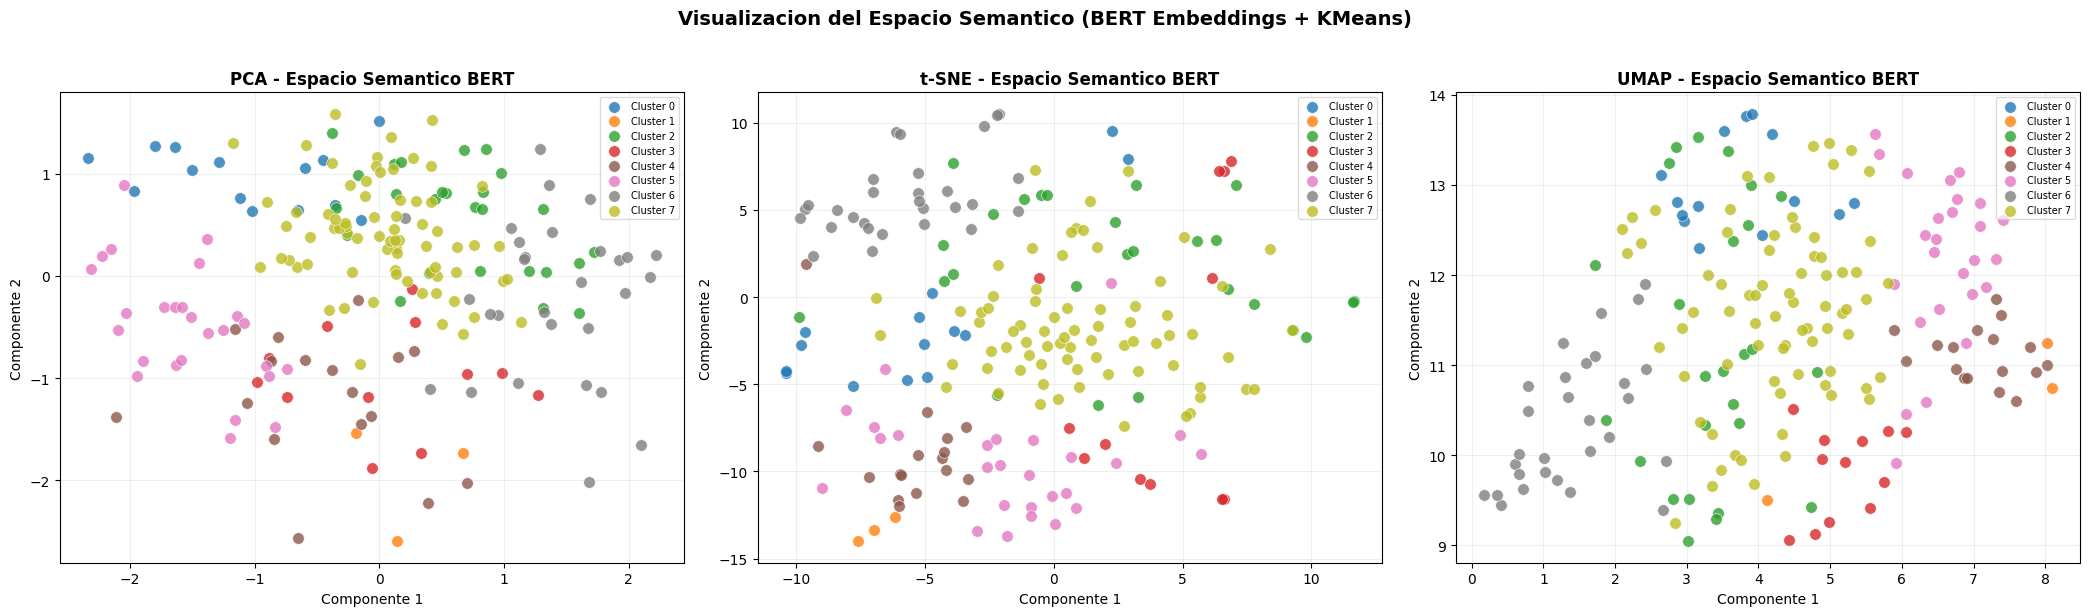

In [ ]:
# --- 6.4 Graficos de las tres tecnicas ---

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

configuraciones = [
    (emb_pca,  "PCA - Espacio Semantico BERT"),
    (emb_tsne, "t-SNE - Espacio Semantico BERT"),
    (emb_umap, "UMAP - Espacio Semantico BERT")
]

for ax, (emb, titulo) in zip(axes, configuraciones):
    for cluster_id in range(N_CLUSTERS):
        mask = etiquetas_cluster == cluster_id
        ax.scatter(
            emb[mask, 0], emb[mask, 1],
            c=[colores_map[cluster_id]],
            label=f"Cluster {cluster_id}", s=70, alpha=0.8,
            edgecolors="white", linewidths=0.5
        )
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_xlabel("Componente 1")
    ax.set_ylabel("Componente 2")
    ax.legend(fontsize=7, loc="best", framealpha=0.7)
    ax.grid(True, alpha=0.2)

plt.suptitle("Visualizacion del Espacio Semantico (BERT Embeddings + KMeans)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("espacio_semantico.png", dpi=130, bbox_inches="tight")
plt.show()

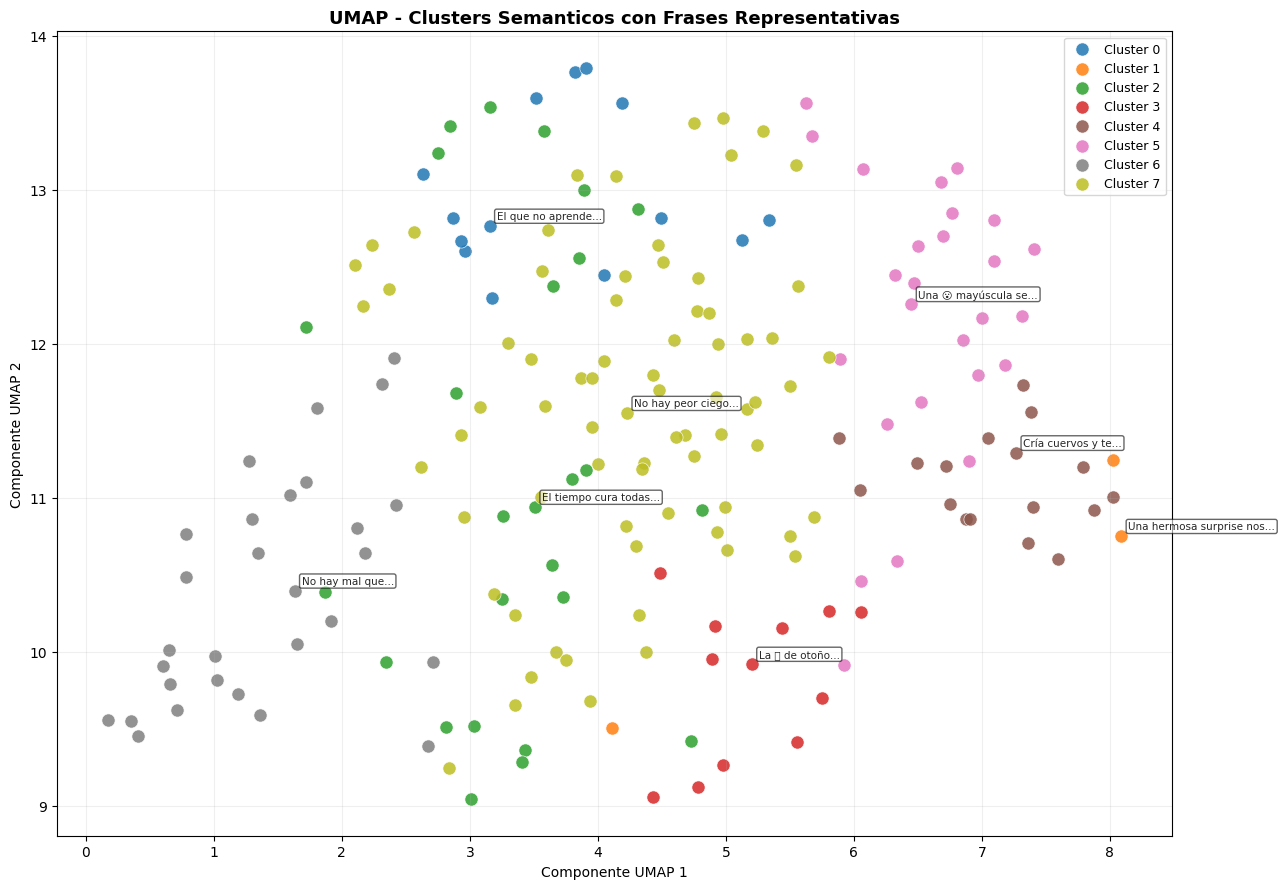

Frases por cluster (muestra de 3 por cluster):
Cluster 0:
  - Vivir con fear es vivir a medias, prefiere la freedom.
  - El mundo es de los audaces que buscan su propio path.
  - La ignorancia es atrevida y causa mucha 😮 en la gente.
Cluster 1:
  - Una grata surprise fue recibir tu carta después de años.
  - La 😮 de los niños al ver los regalos fue hermosa.
  - Una hermosa surprise nos preparó la familia para el aniversario.
Cluster 2:
  - El que madruga Dios lo ayuda con mucho 💰 y salud.
  - Cada loco con su tema y su propia idea de la life.
  - El amor todo lo puede, borra el pain y trae 😊.
Cluster 3:
  - Quien siembra vientos, recoge tempestades y mucha 🌦️.
  - La primavera la sangre altera y trae días llenos de 🌦️.
  - El sol sale para todos, incluso después de la 🌦️.
Cluster 4:
  - Más vale pájaro en mano que Ciento Volando, qué gran surprise.
  - Cría cuervos y te sacarán los ojos, qué terrible surprise.
  - Dime con quién andas y te diré quién eres, qué gran surprise.
Cluster 5:

In [ ]:
# --- 6.5 Zoom UMAP con etiquetas de frases representativas ---

fig, ax = plt.subplots(figsize=(13, 9))

for cluster_id in range(N_CLUSTERS):
    mask = etiquetas_cluster == cluster_id
    puntos = emb_umap[mask]
    ax.scatter(puntos[:, 0], puntos[:, 1],
               c=[colores_map[cluster_id]], label=f"Cluster {cluster_id}",
               s=90, alpha=0.85, edgecolors="white", linewidths=0.5)

# Anotar una frase representativa por cluster (la más cercana al centroide)
centroides_2d = np.array([
    emb_umap[etiquetas_cluster == i].mean(axis=0) for i in range(N_CLUSTERS)
])
for i in range(N_CLUSTERS):
    idx_rep = np.where(etiquetas_cluster == i)[0]
    dists = np.linalg.norm(emb_umap[idx_rep] - centroides_2d[i], axis=1)
    idx_cercano = idx_rep[dists.argmin()]
    etq = " ".join(str(df["frase"].iloc[idx_cercano]).split()[:4]) + "..."
    ax.annotate(etq,
                xy=(emb_umap[idx_cercano, 0], emb_umap[idx_cercano, 1]),
                fontsize=7.5, alpha=0.85,
                xytext=(5, 5), textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))

ax.set_title("UMAP - Clusters Semanticos con Frases Representativas",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Componente UMAP 1")
ax.set_ylabel("Componente UMAP 2")
ax.legend(fontsize=9, loc="best", framealpha=0.8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("umap_clusters_etiquetas.png", dpi=130, bbox_inches="tight")
plt.show()

# Mostrar frases por cluster para interpretación
print("Frases por cluster (muestra de 3 por cluster):")
for i in range(N_CLUSTERS):
    print(f"Cluster {i}:")
    muestra = df[df["cluster"] == i]["frase"].head(3).tolist()
    for frase in muestra:
        print(f"  - {frase[:80]}")

### Análisis - Actividad 6

**Interpretación de los resultados de visualización:**

- **PCA** es lineal y preserva la varianza global, pero tiende a comprimir clusters que se superponen en el espacio de alta dimensión. Es útil como primera exploración.

- **t-SNE** es no lineal y se especializa en preservar la estructura local (vecindades), mostrando clusters bien definidos. Sin embargo, las distancias entre clusters no son directamente interpretables y los resultados pueden variar según la `perplexity`.

- **UMAP** preserva tanto la estructura local como global, produce resultados más estables y consistentes que t-SNE, y es significativamente más rápido. Es actualmente la técnica preferida para visualizar espacios de embeddings.

En todos los gráficos se puede observar que frases de la misma categoría semántica (animales, comida, emociones) tienden a agruparse en regiones cercanas del espacio, lo que confirma que BERT captura coherentemente el significado semántico.

---
## 5. Análisis de Métricas Comparativo

In [ ]:
# Tabla comparativa visual

datos_tabla = {
    "Tecnica":            ["One-Hot", "Word2Vec (propio)", "GloVe", "FastText", "BERT / Sentence-BERT"],
    "Dimensionalidad":    ["Muy Alta (|V|)", "100-300", "300", "300", "768"],
    "Captura Semantica":  ["Ninguna", "Media", "Alta", "Alta", "Muy Alta"],
    "Manejo OOV":         ["Excelente", "Pobre", "Pobre", "Excelente", "Excelente"],
    "Velocidad":          ["Muy Rapida", "Rapida", "Rapida", "Rapida", "Lenta"],
    "Caso de Uso":        [
        "Modelos clasicos",
        "Dominio especifico",
        "Tareas generales",
        "Idiomas morfologicos",
        "Busqueda semantica, RAG"
    ]
}

df_tabla = pd.DataFrame(datos_tabla)
print("\nTabla Comparativa de Tecnicas de Embeddings:")
print(df_tabla.to_string(index=False))


Tabla Comparativa de Tecnicas de Embeddings:
             Tecnica Dimensionalidad Captura Semantica Manejo OOV  Velocidad             Caso de Uso
             One-Hot  Muy Alta (|V|)           Ninguna  Excelente Muy Rapida        Modelos clasicos
   Word2Vec (propio)         100-300             Media      Pobre     Rapida      Dominio especifico
               GloVe             300              Alta      Pobre     Rapida        Tareas generales
            FastText             300              Alta  Excelente     Rapida    Idiomas morfologicos
BERT / Sentence-BERT             768          Muy Alta  Excelente      Lenta Busqueda semantica, RAG


---
## Preguntas de Análisis

### 1. ¿En qué casos prefieres embeddings estáticos vs contextuales?

**Embeddings estáticos (Word2Vec, GloVe, FastText)** son preferibles cuando:
- Los recursos computacionales son limitados (producción en tiempo real, dispositivos edge).
- El corpus es de dominio muy específico y los embeddings se entrenan sobre él.
- Las palabras del vocabulario son técnicas y no polisémicas (terminología médica, legal).
- Se necesita velocidad de inferencia alta con grandes volúmenes de texto.

**Embeddings contextuales (BERT, RoBERTa, Sentence-BERT)** son preferibles cuando:
- El texto contiene palabras polisémicas cuyo significado depende del contexto.
- Se construyen sistemas de preguntas y respuestas, resumen automático o búsqueda semántica.
- La calidad de la representación es más importante que la velocidad de procesamiento.
- Se implementa RAG (Retrieval-Augmented Generation).

---

### 2. ¿Qué técnica es mejor para el español?

Para el español, **FastText es la mejor opción entre los estáticos**, y **Sentence-BERT multilingüe es la mejor opción contextual**.

El español tiene alta riqueza morfológica: los verbos se conjugan en más de 50 formas, los sustantivos tienen género y número, y existen prefijos y sufijos productivos. FastText maneja naturalmente estas variantes gracias a su arquitectura basada en n-gramas de caracteres. GloVe, al trabajar solo con palabras completas, trataría *corría*, *corrió*, *corriendo* como tres tokens distintos sin relación entre ellos.

En el espacio contextual, el modelo `paraphrase-multilingual-MiniLM-L12-v2` o `multilingual-e5-large` (entrenados sobre datos en español) ofrecen excelentes resultados para tareas de similitud semántica.

---

### 3. ¿Cómo impacta la calidad del preprocesamiento en los embeddings?

El preprocesamiento impacta directamente en la calidad de los embeddings entrenados:

- **Normalización de mayúsculas**: sin lowercasing, *Ecuador* y *ecuador* serían dos tokens distintos con vectores independientes, perdiendo contexto compartido.
- **Eliminación de ruido**: caracteres especiales, URLs, números sin contexto semántico añaden tokens irrelevantes que distorsionan las co-ocurrencias.
- **Tokenización adecuada**: una tokenización por subpalabras (como la de BERT) permite representar términos compuestos y morfología flexiva.
- **Stopwords**: su eliminación reduce dimensionalidad en modelos de bolsa de palabras, pero puede perjudicar a modelos de lenguaje que necesitan el contexto completo.

Un preprocesamiento deficiente puede hacer que el modelo aprenda representaciones ruidosas donde palabras semánticamente equivalentes tengan vectores lejanos en el espacio latente.

---

### 4. ¿Qué limitaciones se observaron?

- **Tamaño del corpus**: con solo 52 frases, los modelos Word2Vec entrenados desde cero tienen un vocabulario pequeño y las analogías semánticas no funcionan correctamente. Los embeddings de calidad requieren millones de tokens.
- **Modelos pre-entrenados en inglés**: GloVe y el FastText de gensim están optimizados para inglés. Para producción en español, se deben usar modelos descargados directamente de fasttext.cc o Hugging Face.
- **Costo computacional de BERT**: la inferencia con BERT es significativamente más lenta que con métodos estáticos, lo que puede ser prohibitivo en sistemas de alta demanda sin aceleración GPU.
- **Sesgos en embeddings pre-entrenados**: los modelos aprenden los sesgos presentes en los textos de entrenamiento (sesgos de género, raciales, culturales), lo cual puede propagarse a aplicaciones de producción.
- **Interpretabilidad**: los vectores de alta dimensión no son interpretables por sí mismos; solo se puede analizar su comportamiento relativo mediante similitudes y visualizaciones.